# Networks, language, and emotions during a Californian emergency on Bluesky

**Network structure:** Nodes represent users; edges capture likes, reposts, and comments.

**Emotion vs. influence:** Are the most reposted posts also the most emotional?

**Community detection:** Identify user communities through interaction networks (e.g., Louvain algorithm).

**Community language:** Analyze each community's vocabulary using TF-IDF.

**Behavioral differences:** Compare communities by sentiment (how they *feel*) and vocabulary (how they *talk*), and track how it evolves (before, during, and after the disaster).

**Information roles:** Identify authorities, misinformation spreaders, and bridge nodes (e.g., science communicators) and examine how their language differs.

In [ ]:
from atproto import Client
from datetime import datetime

# Initialize client
client = Client()
client.login("your-username", "your-account-password/app-password")

## Getting the data

In [ ]:
import json, time, math
from datetime import datetime, timezone

START = datetime(2025, 1, 1, 0, 0, tzinfo=timezone.utc) # Jan 1st
END   = datetime(2025, 2, 7, 0, 0, tzinfo=timezone.utc) # Feb 7th

POST_FILE  = 'ca_fire_20250101_20250207.jsonl'
INTERACT_FILE= 'interactions_20250101_20250207.jsonl'
LOG_FILE   = 'all_read_dates.txt'

def safe_get(model, path, default=None):
    """walk dot-notation path safely:  safe_get(post, 'record.reply.parent.uri')"""
    for part in path.split('.'):
        model = getattr(model, part, None)
        if model is None:
            return default
    return model or default

def fetch_all_pages(endpoint, params):
    """generic cursor paginator that yields every item in endpoint(params)."""
    cursor = None
    while True:
        try:
            params['cursor'] = cursor
            rsp = endpoint(params)
            yield from getattr(rsp, 'feed', []) or getattr(rsp, 'likes', []) or getattr(rsp, 'reposted_by', [])
            cursor = getattr(rsp, 'cursor', None)
            if not cursor:
                break
            time.sleep(0.2)
        except Exception as e:
            print('paginator error:', e)
            time.sleep(2)

total_posts = 0
cursor      = None
log         = open(LOG_FILE, 'w', encoding='utf8')

'''
while True:
    try:
        rsp = client.app.bsky.feed.search_posts({'q':'#california fire', 'limit':100, 'cursor':cursor})
    except Exception as e:
        print('search error:', e); time.sleep(2); continue
    if not rsp.posts:
        break

    for p in rsp.posts:
        ts = datetime.fromisoformat(p.record.created_at.replace('Z','+00:00'))
        print(ts.date(), ts.time(), file=log)

        if ts >= END:          # too new
            continue
        if ts < START:         # too old → stop
            cursor = None
            break

        # ---------- core post row ----------
        row = {
            "uri"          : p.uri,
            "cid"          : p.cid,
            "created_at"   : p.record.created_at,
            "indexed_at"   : p.indexed_at,
            "author_did"   : p.author.did,
            "author_handle": p.author.handle,
            "text"         : p.record.text,
            "langs"        : getattr(p.record, 'langs', []),
            "reply_to"     : safe_get(p, 'record.reply.parent.uri'),
            "quoted"       : safe_get(p, 'record.embed.record.uri'),
            "like_count"   : p.like_count or 0,
            "repost_count" : p.repost_count or 0
        }
        with open(POST_FILE, 'a', encoding='utf8') as f:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
        total_posts += 1

        # ---------- interaction rows ----------
        # 1) likes
        for like in fetch_all_pages(client.app.bsky.feed.get_likes,
                                    {'uri': p.uri, 'cid': p.cid, 'limit': 100}):
            with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                f.write(json.dumps({
                    'src_did': like.actor.did,
                    'dst_uri': p.uri,
                    'edge'   : 'like'
                }) + '\n')

        # 2) reposts
        for rep in fetch_all_pages(client.app.bsky.feed.get_reposted_by,
                                   {'uri': p.uri, 'cid': p.cid, 'limit': 100}):
            with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                f.write(json.dumps({
                    'src_did': rep.did,
                    'dst_uri': p.uri,
                    'edge'   : 'repost'
                }) + '\n')

        # 3) replies (store the comment text too)
        try:
            thread = client.app.bsky.feed.get_post_thread({'uri': p.uri, 'cid': p.cid, 'depth': 1})
            for kid in (thread.thread.replies or []):
                row = {
                    'src_did': kid.post.author.did,
                    'dst_uri': p.uri,
                    'edge': 'reply',
                    'reply_text': kid.post.record.text   # <-- children text
                }
                with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                    f.write(json.dumps(row, ensure_ascii=False) + '\n')
        except Exception:
            pass   # no thread / no replies

    cursor = getattr(rsp, 'cursor', None)
    if not cursor:
        break

log.close()
print("finished -> posts:", total_posts,
      "  (interactions appended to", INTERACT_FILE + ")")
'''

### Data preprocessing and exploration

- Preprocess the posts by lower-casing, removing words following @/# (e.g. hashtags, mentions), removing URLs and emojis, and dropping English stop-words
- Basic network statistics
- Comparison of "fire"-related posts tagged within `#California` in January 2025 versus the rest of the year (until October).
- Temporal distribution of posts during January 2025 and early February 2025.

In [5]:
import pandas as pd
import re, string, nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop_en = set(stopwords.words('english'))

# ---------- load ----------
posts  = pd.read_json('ca_fire_20250101_20250207.jsonl', lines=True)
interact = pd.read_json('interactions_20250101_20250207.jsonl', lines=True)

# ---------- regexes & cleaning fn (kept from your original) ----------
url_re   = re.compile(r'https?://\S+')
# NOTE: keep hashtag removal or not depending on whether you want to preserve hashtags
mention_re = re.compile(r'[@#]\w+')
emoji_re = re.compile("["                                
    u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF" u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF" u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)
scanner_re = re.compile(r'\b(?:live audio feed|/webplayer/)\b')

def clean(text):
    if not isinstance(text, str):
        return ''
    t = text.lower()
    t = url_re.sub(' ', t)
    t = mention_re.sub(' ', t)
    t = emoji_re.sub(' ', t)
    t = scanner_re.sub(' ', t)
    tokens = [w for w in t.split() if w not in stop_en and w not in string.punctuation]
    return ' '.join(tokens)

# ---------- apply cleaning ----------
posts['clean_text'] = posts['text'].apply(clean)

# ---------- drop scanner spam ----------
posts = posts[~posts['clean_text'].str.contains(
    r'live audio feed|/webplayer/|dispatch[\s,]*\d+(?:[,\s]+\d+)*', na=False)]

# ---------- deduplicate by URI ----------
# keep the first occurrence of each unique post URI
before_rows = len(posts)
posts = posts.drop_duplicates(subset='uri', keep='first').reset_index(drop=True)
after_rows = len(posts)

# ---------- create sets of unique URIs ----------
posts_uris = set(posts['uri'].dropna())
interacted_dst_uris_all = set(interact['dst_uri'].dropna())

# ---------- interactions that point to posts *we have* ----------
interacted_in_dataset = interacted_dst_uris_all & posts_uris

# ---------- lonely posts (unique posts with zero interactions in our filtered interactions) ----------
lonely_uris = posts_uris - interacted_in_dataset

# ---------- optionally, filter interactions to only those relevant to our post-set ----------
interact_filtered = interact[interact['dst_uri'].isin(posts_uris)].copy()

# ---------- compute user set (authors in posts + sources of interactions that we kept) ----------
users = set(posts['author_did'].dropna()) | set(interact_filtered['src_did'].dropna())

# ---------- print summary stats (consistent) ----------
print("=== dataset cleaning & dedupe ===")
print(f"Rows after scanning-spam filter (before dedupe): {before_rows}")
print(f"Rows after dedupe by uri: {after_rows}")
print()

print("=== URI / interaction summary (unique-URI basis) ===")
total_unique_posts = len(posts_uris)
print(f"Total unique clean posts: {total_unique_posts:,}")
print(f"Unique post URIs that appear as interaction targets (in our interact file): {len(interacted_in_dataset):,}")
print(f"Unique post URIs with zero interactions: {len(lonely_uris):,}")
print(f"Check sum (unique targets + lonely) == total_unique_posts -> "
      f"{len(interacted_in_dataset) + len(lonely_uris)} == {total_unique_posts}")
print()

print("=== interactions (filtered to posts we retained) ===")
print(f"Total interaction rows (original interactions file): {len(interact):,}")
print(f"Interaction rows after filtering to dst_uri in our posts: {len(interact_filtered):,}")
print("Interaction types (filtered):")
if 'edge' in interact_filtered.columns:
    counts = interact_filtered['edge'].value_counts()
    for t, n in counts.items():
        print(f"{t:8s}: {n:,}")
else:
    print("No 'edge' column found in interactions dataframe.")

print()
print(f"Distinct users (authors in posts ∪ src_did of filtered interactions): {len(users):,}")

# ---------- show first 10 cleaned posts for inspection ----------
print()
print("=== first 10 cleaned posts (after filtering & dedupe) ===")
with pd.option_context('display.max_colwidth', None):
    print(posts['clean_text'].head(10).to_string(index=False))

=== dataset cleaning & dedupe ===
Rows after scanning-spam filter (before dedupe): 1284
Rows after dedupe by uri: 1284

=== URI / interaction summary (unique-URI basis) ===
Total unique clean posts: 1,284
Unique post URIs that appear as interaction targets (in our interact file): 765
Unique post URIs with zero interactions: 519
Check sum (unique targets + lonely) == total_unique_posts -> 1284 == 1284

=== interactions (filtered to posts we retained) ===
Total interaction rows (original interactions file): 8,809
Interaction rows after filtering to dst_uri in our posts: 8,782
Interaction types (filtered):
like    : 6,935
repost  : 1,349
reply   : 498

Distinct users (authors in posts ∪ src_did of filtered interactions): 6,675

=== first 10 cleaned posts (after filtering & dedupe) ===
                                                                                                   ap.com: utility says equipment likely started small blaze erupted january's la firestorm
                   

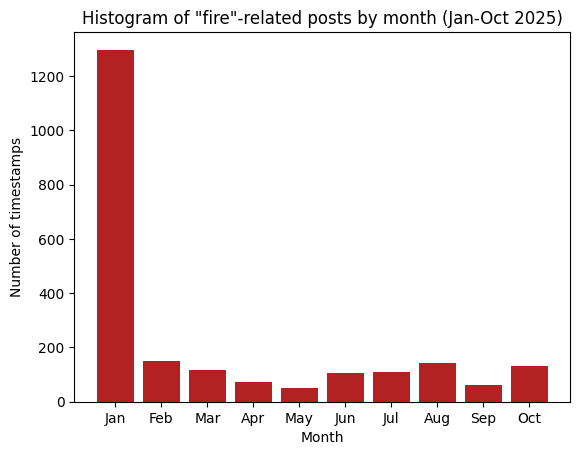

In [30]:
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt

# Read the file
with open('all_read_dates.txt', 'r') as f:
    lines = f.readlines()

# Parse months from lines (ignore year != 2025)
months = []
for line in lines:
    line = line.strip()
    if not line:
        continue
    dt = datetime.fromisoformat(line)
    if dt.year == 2025:  # ignore other years
        months.append(dt.month)

# Count occurrences per month
month_counts = Counter(months)

# Prepare data for plotting (ignore November and December)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct"]  # up to October only

counts = [month_counts.get(i, 0) for i in range(1, 11)]  # months 1–10 only

# Plot histogram
plt.bar(month_names, counts, color='firebrick')
plt.xlabel('Month')
plt.ylabel('Number of timestamps')
plt.title('Histogram of "fire"-related posts by month (Jan-Oct 2025)')
plt.show()

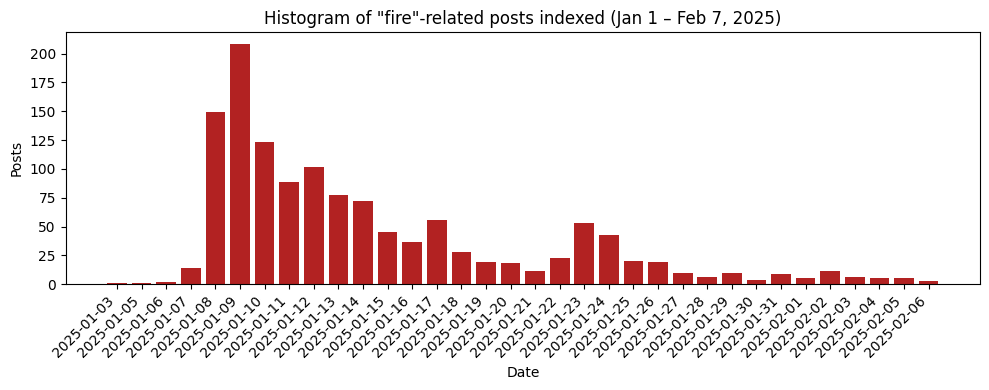

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- use already-cleaned df from upstream cell --------------------------------
# posts  -> cleaned & de-duped dataframe in memory
# interact_filtered -> interactions whose dst_uri exists in posts

# --- convert indexed_at to day ------------------------------------------------
posts["day"] = pd.to_datetime(posts["indexed_at"], utc=True).dt.date

# --- daily counts -------------------------------------------------------------
daily_counts = posts["day"].value_counts().sort_index()

# --- plot ---------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.bar(daily_counts.index.astype(str), daily_counts.values, color='firebrick')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Date")
plt.ylabel("Posts")
plt.title("Histogram of \"fire\"-related posts indexed (Jan 1 – Feb 7, 2025)")
plt.tight_layout()
plt.show()

## Network analysis

In [28]:
import networkx as nx
import numpy as np
import pandas as pd

# --- prepare mapping uri -> author_did (ensure no NaNs) ---
uri_to_author = posts.set_index('uri')['author_did'].to_dict()

# --- build directed graph, using weight to count multiple interactions ---
G = nx.DiGraph()
# add all users as nodes (optional but helpful)
all_users = set(posts['author_did'].dropna()) | set(interact_filtered['src_did'].dropna())
G.add_nodes_from(all_users)

# iterate interactions and add edges (src_did -> author_did_of_dst_uri)
edge_rows = 0
missing_targets = 0
for r in interact_filtered.itertuples(index=False):
    src = getattr(r, 'src_did', None)
    dst_uri = getattr(r, 'dst_uri', None)
    if pd.isna(src) or pd.isna(dst_uri):
        continue
    dst = uri_to_author.get(dst_uri)
    if dst is None:
        missing_targets += 1
        continue
    edge_rows += 1
    if G.has_edge(src, dst):
        G[src][dst]['weight'] += 1
    else:
        G.add_edge(src, dst, weight=1)

print(f"Interaction rows processed into edges: {edge_rows:,}  (missing targets: {missing_targets:,})")
print(f"Nodes in graph: {G.number_of_nodes():,}, edges (unique pairs): {G.number_of_edges():,}")
print()

# --- degree measures ---
# unweighted (number of distinct neighbours)
in_deg_unw = dict(G.in_degree())           # number of incoming neighbors (unweighted)
out_deg_unw = dict(G.out_degree())         # number of outgoing neighbors (unweighted)

# weighted (sum of interaction counts)
in_deg_w = dict(G.in_degree(weight='weight'))
out_deg_w = dict(G.out_degree(weight='weight'))

# convert to pandas Series for convenient stats and filtering
s_in_unw  = pd.Series(in_deg_unw).astype(int)
s_out_unw = pd.Series(out_deg_unw).astype(int)
s_in_w    = pd.Series(in_deg_w).astype(int)
s_out_w   = pd.Series(out_deg_w).astype(int)

# --- for the moment no restriction in interacting users ---
# For in-degree stats: users with in-degree >= 0 (no restriction)
in_users_mask_unw  = s_in_unw >= 0
in_users_mask_w    = s_in_w >= 0

# For out-degree stats: users with out-degree >= 0 (no restriction)
out_users_mask_unw = s_out_unw >= 0
out_users_mask_w   = s_out_w >= 0

def print_stats(series, label):
    arr = series.values
    print(label)
    print(f" Count: {len(arr):,}")
    if len(arr) == 0:
        print("  (no data)\n")
        return
    print(f" Mean  : {arr.mean():.3f}")
    print(f" Median: {np.median(arr):.0f}")
    print(f" Min   : {arr.min():.0f}")
    print(f" Max   : {arr.max():.0f}")
    print(f" Std   : {arr.std(ddof=0):.3f}")   # population std
    print()

# --- print concise stats ---
print("=== UNWEIGHTED degree stats (counts of distinct neighbours) ===")
print_stats(s_in_unw[in_users_mask_unw],  "In-degree (users with in-degree >= 0)")
print_stats(s_out_unw[out_users_mask_unw],"Out-degree (users with out-degree >= 0)")

print("=== WEIGHTED degree stats (sum of interaction counts per node) ===")
print_stats(s_in_w[in_users_mask_w],      "Weighted in-degree (users with weighted in-degree >= 0)")
print_stats(s_out_w[out_users_mask_w],    "Weighted out-degree (users with weighted out-degree >= 0)")

# --- optional: show top-k contributors/receivers ---
TOP_K = 10
print("Top receivers by weighted in-degree (user_did, weight):")
print(s_in_w.sort_values(ascending=False).head(TOP_K).to_string())
print()
print("Top sources by weighted out-degree (user_did, weight):")
print(s_out_w.sort_values(ascending=False).head(TOP_K).to_string())

Interaction rows processed into edges: 8,782  (missing targets: 0)
Nodes in graph: 6,675, edges (unique pairs): 6,907

=== UNWEIGHTED degree stats (counts of distinct neighbours) ===
In-degree (users with in-degree >= 0)
 Count: 6,675
 Mean  : 1.035
 Median: 0
 Min   : 0
 Max   : 776
 Std   : 16.421

Out-degree (users with out-degree >= 0)
 Count: 6,675
 Mean  : 1.035
 Median: 1
 Min   : 0
 Max   : 77
 Std   : 1.144

=== WEIGHTED degree stats (sum of interaction counts per node) ===
Weighted in-degree (users with weighted in-degree >= 0)
 Count: 6,675
 Mean  : 1.316
 Median: 0
 Min   : 0
 Max   : 959
 Std   : 21.325

Weighted out-degree (users with weighted out-degree >= 0)
 Count: 6,675
 Mean  : 1.316
 Median: 1
 Min   : 0
 Max   : 77
 Std   : 1.572

Top receivers by weighted in-degree (user_did, weight):
did:plc:4l3smgwfawe4g4g67xynzkb7    959
did:plc:r64wzjtkimyq4vkiddzuu6no    917
did:plc:vqcodp4ycm7mxxnncn66iat5    693
did:plc:w4shf2bmiz2dvzqq6yuyvg6n    457
did:plc:yqfmy2p54vqgek